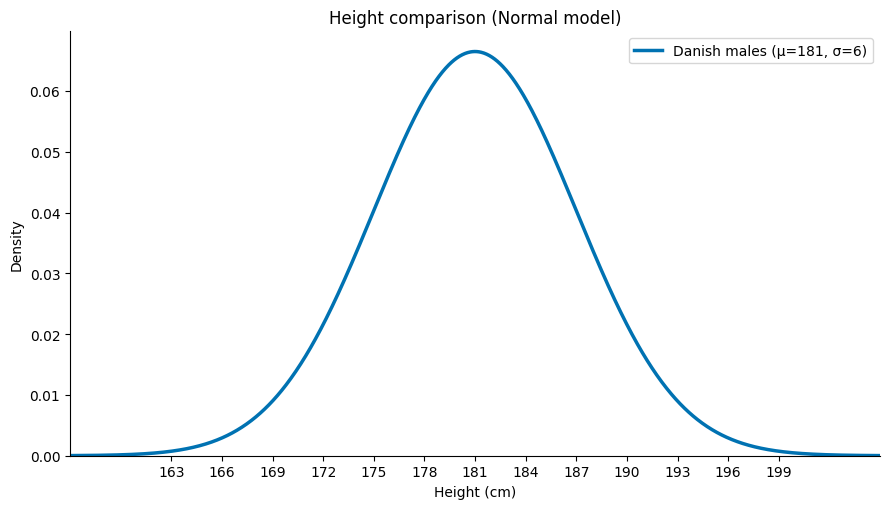

In [8]:
"""
Normal distribution curve plotter (Matplotlib only) — multi-distribution comparison wrapper
WITH:
- show_ticks True/False
- minimalist preset
- presentation_mode preset

What this gives you:
- Plot 1 to 5 normal distributions on the SAME axes (same image)
- Each curve can have its own color and legend label
- Optional shading per distribution (absolute regions + relative-to-mean regions)
- Global x-axis chosen to fit ALL curves nicely
- Curve sits on x-axis (y starts at 0, no bottom padding)
- Only x and y axes (no frame)
- Transparent background export

Presets:
- minimalist=True:
    * removes ticks + tick labels
    * removes axis labels + title
    * removes legend (unless you override show_legend=True)
    * no grid
- presentation_mode=True:
    * bigger fonts, thicker lines, larger legend
    * good for PowerPoint / slides

Requires:
    pip install numpy matplotlib
"""

from __future__ import annotations

from dataclasses import dataclass
from statistics import NormalDist
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import matplotlib.pyplot as plt


Color = Union[str, Tuple[float, float, float]]


# ---------------------------
# Shade region types
# ---------------------------
@dataclass(frozen=True)
class ShadeRegionAbs:
    lower: float
    upper: float
    shade_strength_percent: float = 35.0  # 0..100
    color: Optional[Color] = None
    label: Optional[str] = None


@dataclass(frozen=True)
class ShadeRegionRelToMean:
    """
    Region defined relative to the mean:
        lower = mu - lower_offset
        upper = mu + upper_offset
    """
    lower_offset: float
    upper_offset: float
    shade_strength_percent: float = 35.0  # 0..100
    color: Optional[Color] = None
    label: Optional[str] = None


# ---------------------------
# PDF
# ---------------------------
def normal_pdf(x: np.ndarray, mu: float, sigma: float) -> np.ndarray:
    if sigma <= 0:
        raise ValueError("sigma must be > 0")
    z = (x - mu) / sigma
    return (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * z * z)


# ---------------------------
# Probability-based region builders (optional)
# ---------------------------
def _check_prob(p: float) -> None:
    if not (0.0 < p < 1.0):
        raise ValueError("p must be in (0, 1)")


def central_symmetric_region(
    *, mu: float, sigma: float, p: float, shade_strength_percent: float = 35.0, color: Optional[Color] = None, label: Optional[str] = None
) -> ShadeRegionAbs:
    _check_prob(p)
    z = NormalDist().inv_cdf((1.0 + p) / 2.0)
    return ShadeRegionAbs(
        lower=mu - z * sigma,
        upper=mu + z * sigma,
        shade_strength_percent=shade_strength_percent,
        color=color,
        label=label or f"Central {p:.3f}",
    )


def upper_tail_region(
    *, mu: float, sigma: float, p: float, shade_strength_percent: float = 35.0, color: Optional[Color] = None, label: Optional[str] = None
) -> ShadeRegionAbs:
    _check_prob(p)
    q = NormalDist(mu, sigma).inv_cdf(1.0 - p)
    return ShadeRegionAbs(
        lower=q,
        upper=np.inf,
        shade_strength_percent=shade_strength_percent,
        color=color,
        label=label or f"Upper tail {p:.3f}",
    )


def lower_tail_region(
    *, mu: float, sigma: float, p: float, shade_strength_percent: float = 35.0, color: Optional[Color] = None, label: Optional[str] = None
) -> ShadeRegionAbs:
    _check_prob(p)
    q = NormalDist(mu, sigma).inv_cdf(p)
    return ShadeRegionAbs(
        lower=-np.inf,
        upper=q,
        shade_strength_percent=shade_strength_percent,
        color=color,
        label=label or f"Lower tail {p:.3f}",
    )


def shade_above_threshold(
    *, threshold: float, shade_strength_percent: float = 35.0, color: Optional[Color] = None, label: Optional[str] = None
) -> ShadeRegionAbs:
    return ShadeRegionAbs(
        lower=threshold,
        upper=np.inf,
        shade_strength_percent=shade_strength_percent,
        color=color,
        label=label or f"x ≥ {threshold:g}",
    )


def shade_below_threshold(
    *, threshold: float, shade_strength_percent: float = 35.0, color: Optional[Color] = None, label: Optional[str] = None
) -> ShadeRegionAbs:
    return ShadeRegionAbs(
        lower=-np.inf,
        upper=threshold,
        shade_strength_percent=shade_strength_percent,
        color=color,
        label=label or f"x ≤ {threshold:g}",
    )


# ---------------------------
# Single-curve plotter that draws onto an existing Axes
# ---------------------------
def plot_normal_curve_on_ax(
    *,
    ax: plt.Axes,
    mu: float,
    sigma: float,
    x_min: float,
    x_max: float,
    num_points: int = 1500,
    curve_color: Color = "black",
    curve_linewidth: float = 2.5,
    label: Optional[str] = None,
    shade_abs: Optional[List[ShadeRegionAbs]] = None,
    shade_rel_to_mean: Optional[List[ShadeRegionRelToMean]] = None,
) -> None:
    if sigma <= 0:
        raise ValueError("sigma must be > 0")
    if x_max <= x_min:
        raise ValueError("x_max must be > x_min")

    x = np.linspace(x_min, x_max, num_points)
    y = normal_pdf(x, mu, sigma)

    if label is None:
        label = f"μ={mu:g}, σ={sigma:g}"

    # Curve
    ax.plot(x, y, linewidth=curve_linewidth, color=curve_color, label=label)

    # Collect shading regions into absolute bounds
    regions: List[ShadeRegionAbs] = []
    if shade_abs:
        regions.extend(shade_abs)

    if shade_rel_to_mean:
        for r in shade_rel_to_mean:
            regions.append(
                ShadeRegionAbs(
                    lower=mu - r.lower_offset,
                    upper=mu + r.upper_offset,
                    shade_strength_percent=r.shade_strength_percent,
                    color=r.color,
                    label=r.label,
                )
            )

    # Shade
    for region in regions:
        lower = min(region.lower, region.upper)
        upper = max(region.lower, region.upper)

        lower_clip = x_min if np.isneginf(lower) else max(lower, x_min)
        upper_clip = x_max if np.isposinf(upper) else min(upper, x_max)
        if upper_clip <= lower_clip:
            continue

        alpha = max(0.0, min(1.0, float(region.shade_strength_percent) / 100.0))
        region_color = region.color if region.color is not None else curve_color

        mask = (x >= lower_clip) & (x <= upper_clip)
        ax.fill_between(x[mask], 0.0, y[mask], alpha=alpha, color=region_color, linewidth=0)


# ---------------------------
# Multi-distribution wrapper (1..5 curves)
# ---------------------------
def compare_normal_distributions(
    *,
    distributions: List[Dict[str, Any]],
    # Content
    title: Optional[str] = None,
    xlabel: str = "x",
    ylabel: str = "Density",
    # Behaviour toggles
    show_grid: bool = False,
    show_legend: bool = True,
    legend_loc: str = "best",
    show_ticks: bool = True,
    # Presets
    minimalist: bool = False,
    presentation_mode: bool = False,
    # Curve resolution and x-range rule
    num_points: int = 1500,
    k_sigmas: float = 4.0,
    tick_step: Optional[float] = 2.0,
    # Figure options
    figsize: Tuple[float, float] = (9, 5.2),
    # Save options
    save_path: Optional[str] = None,
    dpi: int = 300,
    transparent_background: bool = True,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    distributions: list of dicts, each item can contain:
        - mu (required)
        - sigma (required)
        - color (optional)
        - label (optional)  -> legend entry
        - linewidth (optional)
        - shade_abs (optional): List[ShadeRegionAbs]
        - shade_rel_to_mean (optional): List[ShadeRegionRelToMean]
    """

    if not (1 <= len(distributions) <= 5):
        raise ValueError("Provide between 1 and 5 distributions.")

    # Apply presets (presets override defaults, but you can still explicitly override args)
    if minimalist:
        show_grid = False
        show_ticks = False
        # Hide legend by default in minimalist mode unless explicitly set by caller
        # (caller can still pass show_legend=True)
        show_legend = False if show_legend is True else show_legend
        title = "" if title is None else title
        xlabel = "" if xlabel == "x" else xlabel
        ylabel = "" if ylabel == "Density" else ylabel

    # Presentation mode tweaks (local to this function; doesn't permanently change matplotlib)
    if presentation_mode:
        plt.rcParams.update(
            {
                "font.size": 14,
                "axes.titlesize": 16,
                "axes.labelsize": 14,
                "legend.fontsize": 12,
                "xtick.labelsize": 12,
                "ytick.labelsize": 12,
            }
        )

    mus: List[float] = []
    sigmas: List[float] = []
    for d in distributions:
        if "mu" not in d or "sigma" not in d:
            raise ValueError("Each distribution must have 'mu' and 'sigma'.")
        mus.append(float(d["mu"]))
        sigmas.append(float(d["sigma"]))

    if any(s <= 0 for s in sigmas):
        raise ValueError("All sigma values must be > 0.")

    max_sigma = max(sigmas)
    min_mu = min(mus)
    max_mu = max(mus)

    # Global x-range: wide enough for all curves
    x_min = min_mu - k_sigmas * max_sigma
    x_max = max_mu + k_sigmas * max_sigma

    # Ticks centered around the mean of means, spanning +/- 3*max_sigma
    mu_center = float(np.mean(mus))
    if tick_step is None:
        tick_step = 2.0
    tick_left = mu_center - 3.0 * max_sigma
    tick_right = mu_center + 3.0 * max_sigma
    x_ticks = np.arange(tick_left, tick_right + 1e-9, float(tick_step))

    fig, ax = plt.subplots(figsize=figsize)

    # Plot each distribution
    for d in distributions:
        mu = float(d["mu"])
        sigma = float(d["sigma"])

        lw = float(d.get("linewidth", 2.5))
        if presentation_mode:
            lw = max(lw, 3.5)

        plot_normal_curve_on_ax(
            ax=ax,
            mu=mu,
            sigma=sigma,
            x_min=x_min,
            x_max=x_max,
            num_points=num_points,
            curve_color=d.get("color", "black"),
            curve_linewidth=lw,
            label=d.get("label", f"μ={mu:g}, σ={sigma:g}"),
            shade_abs=d.get("shade_abs"),
            shade_rel_to_mean=d.get("shade_rel_to_mean"),
        )

    # Title/labels
    if title:
        ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Ticks
    if show_ticks:
        ax.set_xticks(x_ticks)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    # Grid
    if show_grid:
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

    # Curve sits on x-axis, no padding
    ax.set_ylim(bottom=0.0)
    ax.margins(x=0.0, y=0.0)

    # Only x and y axes (no frame)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend
    if show_legend:
        ax.legend(loc=legend_loc)

    fig.tight_layout()

    if save_path:
        fig.savefig(
            save_path,
            dpi=dpi,
            transparent=transparent_background,
            bbox_inches="tight",
            pad_inches=0.02,
        )

    return fig, ax


# ---------------------------
# Example usage
# ---------------------------
if __name__ == "__main__":

    distributions = [
        {"mu": 181, "sigma": 6, "color": "#0072B2", "label": "Danish males (μ=181, σ=6)"},
        # {"mu": 168, "sigma": 5, "color": "#D55E00", "label": "Danish females (μ=168, σ=5)"},
        # Add up to 5:
        # {"mu": 175, "sigma": 7, "color": "black", "label": "Group 3"},
    ]

    # Normal (default)
    compare_normal_distributions(
        distributions=distributions,
        title="Height comparison (Normal model)",
        xlabel="Height (cm)",
        ylabel="Density",
        tick_step=3.0,
        show_ticks=True,
        show_legend=True,
        save_path=r"C:\Users\RIB\Downloads\heights_presentation.png",
        transparent_background=True,
    )

    # Presentation mode (good for slides)
    # compare_normal_distributions(
    #     distributions=distributions,
    #     title="Height comparison (Normal model)",
    #     xlabel="Height (cm)",
    #     ylabel="Density",
    #     presentation_mode=True,
    #     save_path=r"C:\Users\RIB\Downloads\heights_presentation.png",
    #     transparent_background=True,
    # )

    # Minimalist (very clean)
    # compare_normal_distributions(
    #     distributions=distributions,
    #     minimalist=True,
    #     save_path=r"C:\Users\RIB\Downloads\heights_minimalist.png",
    #     transparent_background=True,
    # )

    plt.show()